# Sesión 17: Clustering con K-Means y sus Variaciones

**Objetivos:**
-   Entender la diferencia fundamental entre aprendizaje **supervisado** y **no supervisado**.
-   Aprender la intuición y el funcionamiento del algoritmo **K-Means**.
-   Identificar los desafíos de K-Means, principalmente la elección de **K**.
-   Conocer variaciones como **Mini-Batch K-Means** y **MeanShift**.
-   Aplicar clustering para segmentar clientes y visualizar e interpretar los resultados.

## 1. Un Nuevo Paradigma: Aprendizaje No Supervisado

Hasta ahora, siempre hemos tenido una variable objetivo (`y`) que queríamos predecir. El aprendizaje no supervisado es diferente. No tenemos etiquetas. El objetivo no es predecir, sino **descubrir patrones, estructuras o grupos ocultos** directamente en los datos (`X`).

La tarea más común en el aprendizaje no supervisado es el **clustering** o agrupamiento.

## 2. K-Means: Encontrando el Centro de los Grupos

K-Means es el algoritmo de clustering más famoso. Su objetivo es agrupar los datos en **K** clústeres distintos (donde K es un número que nosotros elegimos).

* **Intuición:** Imagina que tienes que colocar K oficinas de correos en una ciudad para que todos los ciudadanos estén lo más cerca posible de una oficina. K-Means hace algo parecido.
* **¿Cómo funciona?**
    1.  **Inicialización:** Coloca K puntos aleatorios en el mapa de datos. Estos son los "centroides" iniciales.
    2.  **Asignación:** Asigna cada punto de datos al centroide más cercano.
    3.  **Actualización:** Mueve cada centroide al centro geométrico (la media) de todos los puntos que le han sido asignados.
    4.  **Repetición:** Repite los pasos 2 y 3 hasta que los centroides ya no se muevan.

* **El Gran Desafío:** Debemos decidir el valor de **K** (el número de clústeres) antes de empezar. ¿Cómo saber si son 3, 4 o 5 grupos?

## 3. Variaciones de K-Means

* **Mini-Batch K-Means:**
    * **¿Qué es?** Una versión más rápida y eficiente de K-Means.
    * **¿Cómo funciona?** En lugar de usar todos los datos en cada iteración para actualizar los centroides, usa solo un pequeño subconjunto aleatorio ("mini-batch").
    * **¿Cuándo usarlo?** Cuando tienes datasets tan grandes que K-Means es demasiado lento o no cabe en memoria. El resultado es una aproximación ligeramente menos precisa pero mucho más rápida.

* **MeanShift:**
    * **¿Qué es?** Un algoritmo de clustering que **no requiere que le digas el número de clústeres (K)**.
    * **¿Cómo funciona?** Se basa en la densidad. Imagina tus datos como un paisaje con colinas y valles. MeanShift intenta que cada punto "escale" hasta la cima de la colina más cercana. Todos los puntos que terminan en la misma cima pertenecen al mismo clúster. El algoritmo descubre el número de cimas (clústeres) por sí solo.
    * **¿Cuándo usarlo?** Cuando no tienes una idea clara de cuántos clústeres puede haber en tus datos.

---
## Taller de Visualización Aplicada: Segmentación de Clientes

**Contexto:** Somos analistas de un centro comercial y tenemos datos sobre nuestros clientes, incluyendo sus ingresos anuales y una "puntuación de gasto" (del 1 al 100) que hemos creado. Queremos usar clustering para identificar diferentes segmentos de clientes y así poder crear campañas de marketing personalizadas.

### Actividad en Clase:
1.  **Carga y prepara** el dataset "Mall Customers". Para este análisis, solo nos interesan las columnas `Annual Income (k$)` y `Spending Score (1-100)`.
2.  **¡No olvides escalar los datos!** Los algoritmos basados en distancia como K-Means son muy sensibles a la escala.
3.  **Aplica K-Means:** Entrena un modelo `KMeans` con **5 clústeres** (`n_clusters=5`).
4.  **Visualiza los Clústeres:** Crea un **gráfico de dispersión (scatterplot)** de los ingresos anuales vs. la puntuación de gasto. Colorea cada punto según el clúster al que ha sido asignado por el modelo.
5.  **Interpreta los Grupos:** Observando el gráfico, describe brevemente qué representa cada uno de los 5 grupos de clientes.

### Reto para Casa: ¿Cuál es el K Óptimo?
Una de las formas más comunes de elegir K es el **Método del Codo (Elbow Method)**. Consiste en ejecutar K-Means para un rango de valores de K (ej. de 1 a 10) y graficar la "inercia" del modelo para cada K. La "inercia" es una medida de qué tan juntos están los puntos dentro de sus clústeres. Buscamos el punto en el gráfico donde la mejora empieza a ser marginal (el "codo" de la curva).

1.  **Calcula la inercia** para valores de K desde 1 hasta 10.
2.  **Grafica los resultados** (K en el eje x, Inercia en el eje y).
3.  **Responde a las siguientes preguntas de reflexión**:
    * Según tu gráfico, ¿dónde está el "codo"? ¿El valor K=5 que usamos en clase parece una buena elección?
    * Describe los 5 segmentos de clientes que encontraste (ej. "Ingresos altos, gasto bajo"). ¿Qué acción de marketing específica podrías proponer para el segmento de "Ingresos altos, gasto alto"?

Datos cargados correctamente desde el archivo local:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


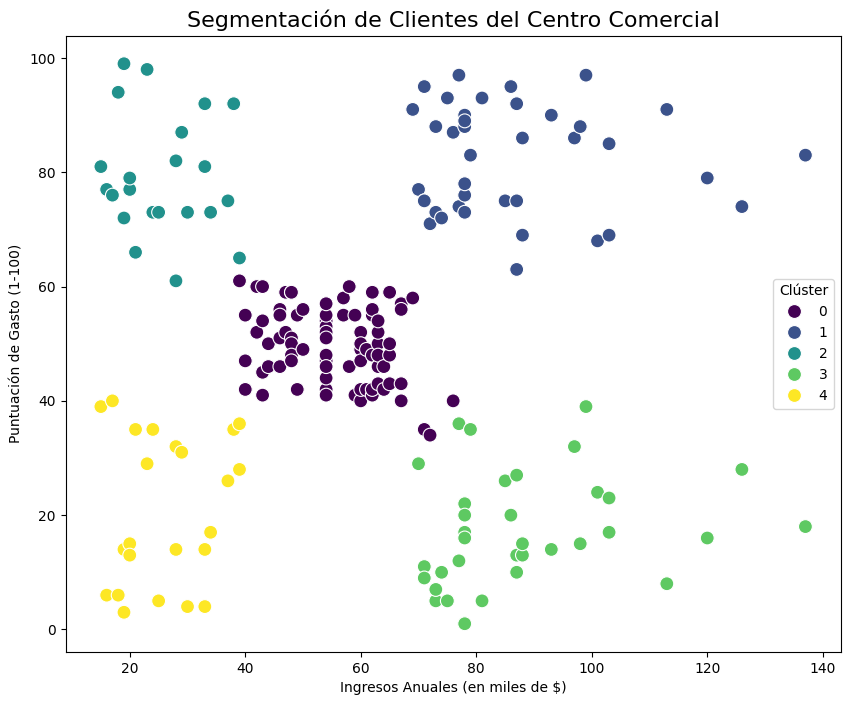

In [6]:
# --- CÓDIGO FINAL USANDO EL ARCHIVO LOCAL ---
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar los datos desde el archivo CSV que has descargado
# Pandas lo buscará en la misma carpeta que tu notebook.
df = pd.read_csv('Mall_Customers.csv')

print("Datos cargados correctamente desde el archivo local:")
print(df.head())

# Seleccionamos las columnas de interés
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 2. Escala los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplica K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Añadimos la etiqueta del clúster al DataFrame original para facilitar la visualización
df['Cluster'] = kmeans.labels_

# 4. Visualiza los Clústeres
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='viridis', s=100)
plt.title('Segmentación de Clientes del Centro Comercial', fontsize=16)
plt.xlabel('Ingresos Anuales (en miles de $)')
plt.ylabel('Puntuación de Gasto (1-100)')
plt.legend(title='Clúster')
plt.show()

5.  **Interpreta los Grupos:** Observando el gráfico, describe brevemente qué representa cada uno de los 5 grupos de clientes.

Cluster 0 ingresos medios, gastos medios

Cluster 1 ingresos altos gastos altos

Cluster 2 Ingresos bajos gastos altos

Cluster 3 ingresos altos gastos bajos

Cluster 4 ingresos bajos gastos altos

---
## Reto para Casa: ¿Cuál es el K Óptimo?
*Usa esta celda para realizar el método del codo y responder a las preguntas.*


### Reto para Casa: ¿Cuál es el K Óptimo?
Una de las formas más comunes de elegir K es el **Método del Codo (Elbow Method)**. Consiste en ejecutar K-Means para un rango de valores de K (ej. de 1 a 10) y graficar la "inercia" del modelo para cada K. La "inercia" es una medida de qué tan juntos están los puntos dentro de sus clústeres. Buscamos el punto en el gráfico donde la mejora empieza a ser marginal (el "codo" de la curva).

1.  **Calcula la inercia** para valores de K desde 1 hasta 10.
2.  **Grafica los resultados** (K en el eje x, Inercia en el eje y).
3.  **Responde a las siguientes preguntas de reflexión**:
    * Según tu gráfico, ¿dónde está el "codo"? ¿El valor K=5 que usamos en clase parece una buena elección?
    * Describe los 5 segmentos de clientes que encontraste (ej. "Ingresos altos, gasto bajo"). ¿Qué acción de marketing específica podrías proponer para el segmento de "Ingresos altos, gasto alto"?

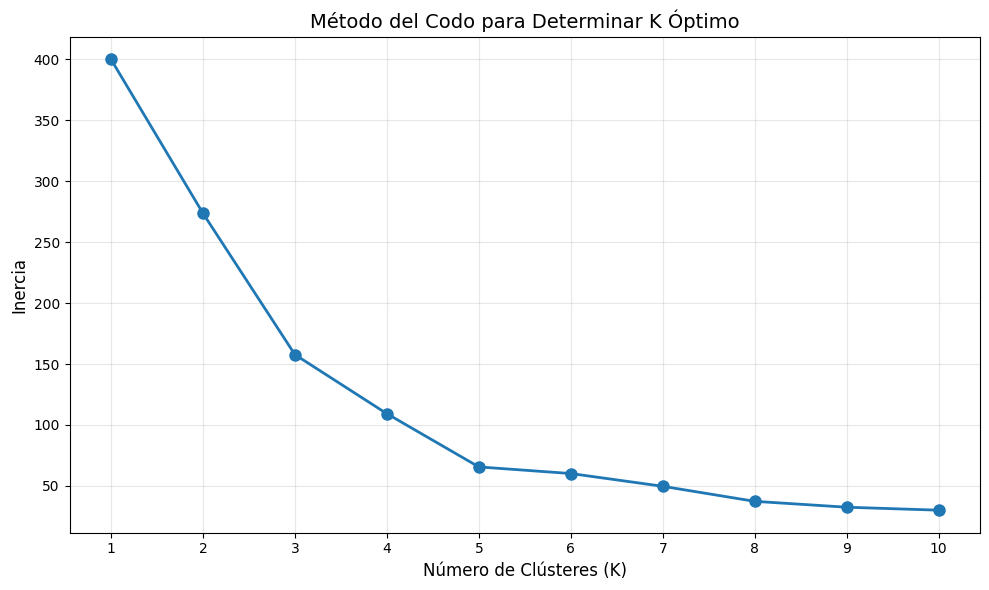


Valores de K e Inercias:
K=1: Inercia=400.00
K=2: Inercia=273.67
K=3: Inercia=157.70
K=4: Inercia=109.23
K=5: Inercia=65.57
K=6: Inercia=60.13
K=7: Inercia=49.67
K=8: Inercia=37.32
K=9: Inercia=32.50
K=10: Inercia=30.06


In [7]:
# --- ESPACIO PARA EL RETO PARA CASA ---
# Calculamos la inercia para valores de K desde 1 hasta 10

inercias = []
k_values = range(1, 11)

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(X_scaled)
    inercias.append(kmeans_temp.inertia_)
    
# Graficamos los resultados
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_values, inercias, marker='o', linewidth=2, markersize=8)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Inercia', fontsize=12)
plt.title('Método del Codo para Determinar K Óptimo', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

print("\nValores de K e Inercias:")
for k, inercia in zip(k_values, inercias):
    print(f"K={k}: Inercia={inercia:.2f}")

Vemos que la inercia deja de mejorar a partir de 5 clusters, podriamos decir que k = 5 es el codo y es la configuracion optima.

Para el segmento de ingresos altos gastos altos pondria tiendas de lujo.

#  Ejercicio Práctico: Logística en California (K-Means vs MeanShift)

## Contexto
Trabajas para una empresa de logística urgente y servicios de emergencia en el estado de California. Dispones de un dataset con la ubicación exacta (Latitud/Longitud) de **20.640 distritos habitados**.

La dirección te plantea dos escenarios operativos distintos y necesitas usar Clustering para resolverlos:

1.  **Escenario "Presupuesto Cerrado" (K-Means):** La empresa tiene presupuesto para construir **exactamente 6 grandes centros de distribución**. Tu misión es encontrar las ubicaciones matemáticas óptimas para minimizar la distancia de viaje a todos los distritos.
2.  **Escenario "Cobertura Natural" (MeanShift):** La empresa quiere saber **cuántos centros debería abrir** si quisiera cubrir los núcleos de población reales (ciudades), sin importar el presupuesto inicial. El algoritmo debe decirte cuántos "clústeres naturales" existen.

## Dataset
Usaremos `fetch_california_housing` de Scikit-Learn.
* Nos quedaremos solo con las columnas geográficas: `Latitude` y `Longitude`.
* **Reto:** Los datos geográficos requieren un preprocesamiento cuidadoso (Escalado) para que las distancias se calculen bien.

---

Cargando censo de California...
Registros cargados: 20,640

Primeras filas:
   Longitude  Latitude
0    -122.23     37.88
1    -122.22     37.86
2    -122.24     37.85
3    -122.25     37.85
4    -122.25     37.85

CENTROS DE DISTRIBUCIÓN (Centroides de los 6 clusters)

Centro 1:
  Latitud:  -118.1248
  Longitud: 34.0136

Centro 2:
  Latitud:  -122.1726
  Longitud: 37.6681

Centro 3:
  Latitud:  -119.6807
  Longitud: 35.9606

Centro 4:
  Latitud:  -121.1367
  Longitud: 38.3990

Centro 5:
  Latitud:  -116.9436
  Longitud: 33.0811

Centro 6:
  Latitud:  -122.7643
  Longitud: 40.1758


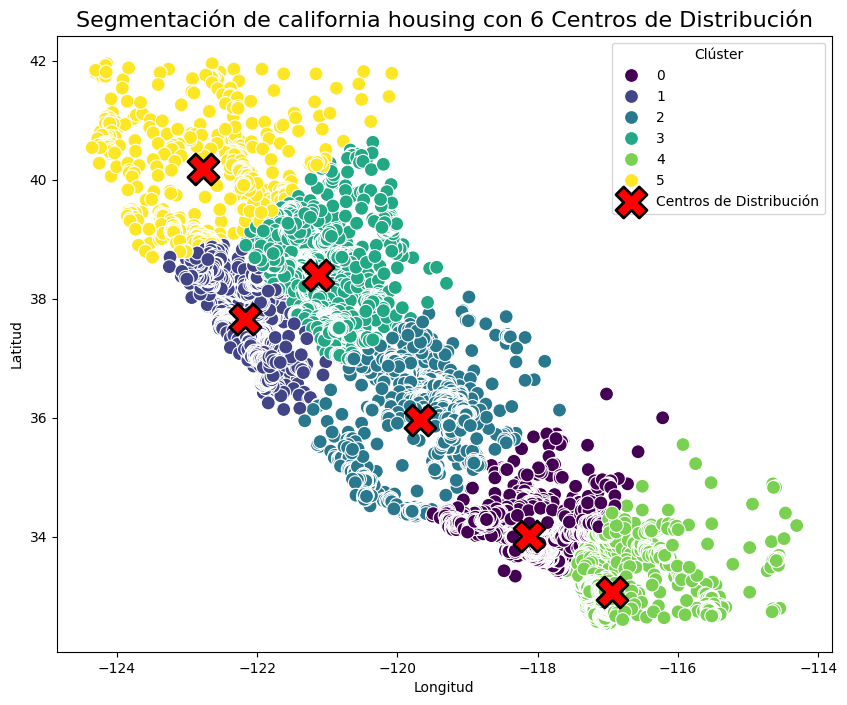

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import fetch_california_housing
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler

# 1. CARGA DE DATOS REALES
print("Cargando censo de California...")
data = fetch_california_housing(as_frame=True)
df_california = data.frame

# Nos quedamos solo con las coordenadas geográficas
X_geo = df_california[['Longitude', 'Latitude']].copy()
print(f"Registros cargados: {len(X_geo):,}")
print(f"\nPrimeras filas:\n{X_geo.head()}")

# 2. ESCALADO DE DATOS
scaler_geo = StandardScaler()
X_geo_scaled = scaler_geo.fit_transform(X_geo)

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(X_geo_scaled)
# Añadimos la etiqueta del clúster al DataFrame original para facilitar la visualización
df_california['Cluster'] = kmeans.labels_

# 3. OBTENER CENTROIDES EN COORDENADAS ORIGINALES
centroides_scaled = kmeans.cluster_centers_
centroides_reales = scaler_geo.inverse_transform(centroides_scaled)

print("\n" + "="*60)
print("CENTROS DE DISTRIBUCIÓN (Centroides de los 6 clusters)")
print("="*60)
for i, centroide in enumerate(centroides_reales):
    print(f"\nCentro {i+1}:")
    print(f"  Latitud:  {centroide[0]:.4f}")
    print(f"  Longitud: {centroide[1]:.4f}")
print("="*60)

# 4. Visualiza los Clústeres
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_california, x='Longitude', y='Latitude', hue='Cluster', palette='viridis', s=100)
plt.scatter(centroides_reales[:, 0], centroides_reales[:, 1], 
            marker='X', s=500, c='red', edgecolors='black', linewidths=2,
            label='Centros de Distribución')
plt.title('Segmentación de california housing con 6 Centros de Distribución', fontsize=16)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Clúster')
plt.show()

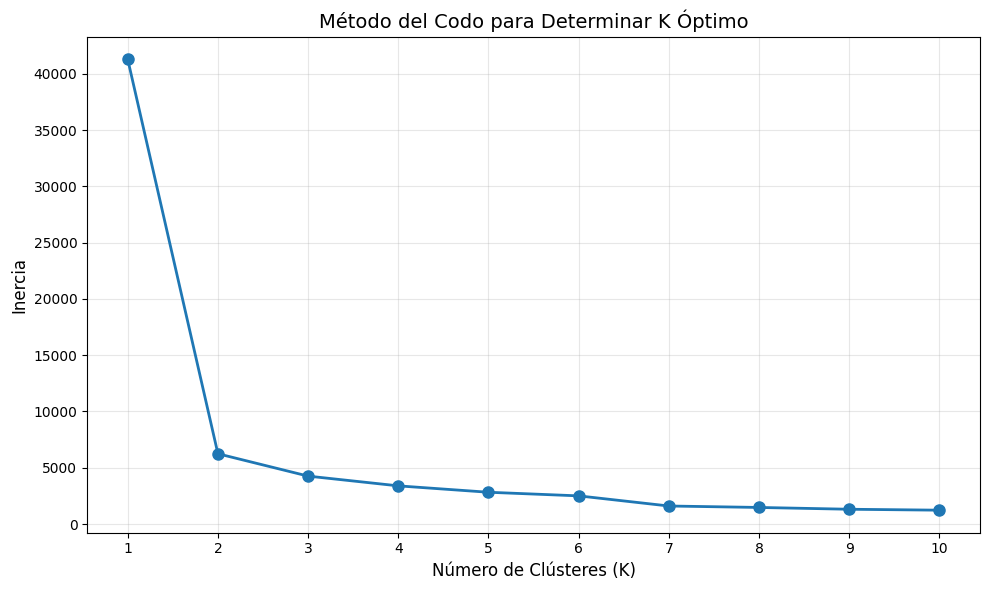


Valores de K e Inercias:
K=1: Inercia=41280.00
K=2: Inercia=6240.83
K=3: Inercia=4254.57
K=4: Inercia=3388.86
K=5: Inercia=2820.59
K=6: Inercia=2499.71
K=7: Inercia=1599.06
K=8: Inercia=1470.39
K=9: Inercia=1310.66
K=10: Inercia=1227.74


In [20]:
inercias = []
k_values = range(1, 11)

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(X_geo_scaled)
    inercias.append(kmeans_temp.inertia_)
    
# Graficamos los resultados
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_values, inercias, marker='o', linewidth=2, markersize=8)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Inercia', fontsize=12)
plt.title('Método del Codo para Determinar K Óptimo', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

print("\nValores de K e Inercias:")
for k, inercia in zip(k_values, inercias):
    print(f"K={k}: Inercia={inercia:.2f}")


ESCENARIO 2: DESCUBRIMIENTO DE NÚCLEOS DE POBLACIÓN CON MEANSHIFT

Calculando bandwidth óptimo...
Bandwidth estimado: 0.3457

Aplicando MeanShift para encontrar clusters naturales...

RESULTADO: Se encontraron 15 núcleos de población naturales
Tiempo de ejecución: 1.57 segundos

Ubicación de los centros de población naturales:

Núcleo 1:
  Latitud:  -118.1475
  Longitud: 33.9798
  Población (distritos): 8,662

Núcleo 2:
  Latitud:  -122.1662
  Longitud: 37.6778
  Población (distritos): 6,504

Núcleo 3:
  Latitud:  -117.1199
  Longitud: 32.8621
  Población (distritos): 1,887

Núcleo 4:
  Latitud:  -119.6458
  Longitud: 36.6186
  Población (distritos): 1,029

Núcleo 5:
  Latitud:  -119.1280
  Longitud: 35.7592
  Población (distritos): 450

Núcleo 6:
  Latitud:  -120.0582
  Longitud: 34.6205
  Población (distritos): 622

Núcleo 7:
  Latitud:  -122.0844
  Longitud: 40.1195
  Población (distritos): 808

Núcleo 8:
  Latitud:  -124.0698
  Longitud: 40.7584
  Población (distritos): 197

Núcle

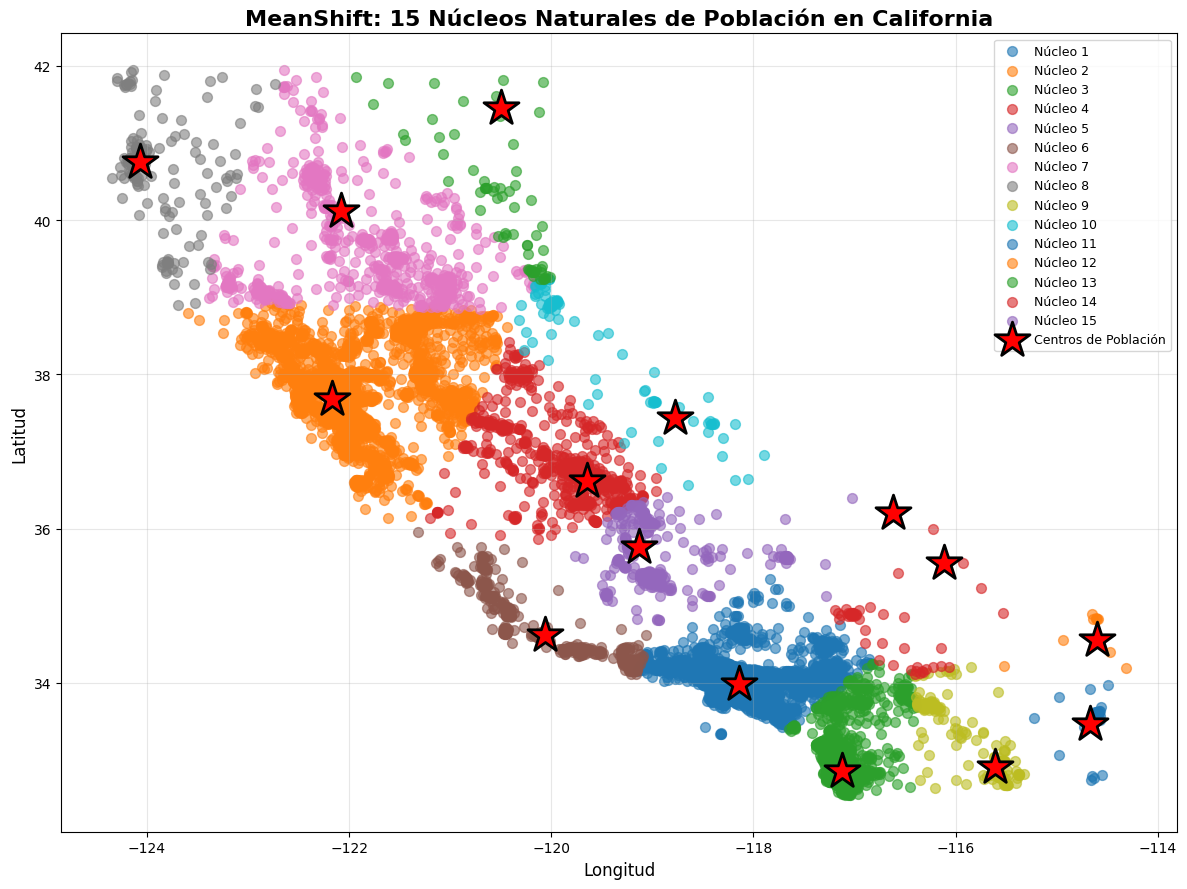


CONCLUSIÓN: MeanShift detectó 15 núcleos naturales de población


In [27]:
# ============================================================
# ESCENARIO 2: "COBERTURA NATURAL" - MEANSHIFT
# ============================================================
print("\n" + "="*70)
print("ESCENARIO 2: DESCUBRIMIENTO DE NÚCLEOS DE POBLACIÓN CON MEANSHIFT")
print("="*70)

# 1. ESTIMAR BANDWIDTH (ancho de banda) 
# Este parámetro es crucial en MeanShift - determina el "radio de búsqueda"
print("\nCalculando bandwidth óptimo...")
bandwidth = estimate_bandwidth(X_geo_scaled, quantile=0.1, n_samples=1000)
print(f"Bandwidth estimado: {bandwidth:.4f}")

# 2. APLICAR MEANSHIFT
print("\nAplicando MeanShift para encontrar clusters naturales...")
start_time = time.time()
meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
meanshift.fit(X_geo_scaled)
tiempo_ejecucion = time.time() - start_time

# 3. RESULTADOS
labels_meanshift = meanshift.labels_
n_clusters_encontrados = len(np.unique(labels_meanshift))
centroides_meanshift_scaled = meanshift.cluster_centers_
centroides_meanshift_reales = scaler_geo.inverse_transform(centroides_meanshift_scaled)

print(f"\n{'='*70}")
print(f"RESULTADO: Se encontraron {n_clusters_encontrados} núcleos de población naturales")
print(f"Tiempo de ejecución: {tiempo_ejecucion:.2f} segundos")
print(f"{'='*70}")

# Mostrar ubicación de cada núcleo
print("\nUbicación de los centros de población naturales:")
for i, centroide in enumerate(centroides_meanshift_reales):
    n_puntos = np.sum(labels_meanshift == i)
    print(f"\nNúcleo {i+1}:")
    print(f"  Latitud:  {centroide[0]:.4f}")
    print(f"  Longitud: {centroide[1]:.4f}")
    print(f"  Población (distritos): {n_puntos:,}")

# 4. VISUALIZACIÓN
df_california['Cluster_MeanShift'] = labels_meanshift

plt.figure(figsize=(12, 9))
for cluster in range(n_clusters_encontrados):
    mask = df_california['Cluster_MeanShift'] == cluster
    plt.scatter(df_california.loc[mask, 'Longitude'],
               df_california.loc[mask, 'Latitude'],
               s=50, alpha=0.6, label=f'Núcleo {cluster+1}')

plt.scatter(centroides_meanshift_reales[:, 0], centroides_meanshift_reales[:, 1],
           marker='*', s=700, c='red', edgecolors='black', linewidths=2,
           label='Centros de Población', zorder=5)

plt.title(f'MeanShift: {n_clusters_encontrados} Núcleos Naturales de Población en California', 
         fontsize=16, weight='bold')
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(f"CONCLUSIÓN: MeanShift detectó {n_clusters_encontrados} núcleos naturales de población")
print("="*70)

### Mis Reflexiones

*(Escribe aquí tus respuestas a las preguntas del reto para casa)*